In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

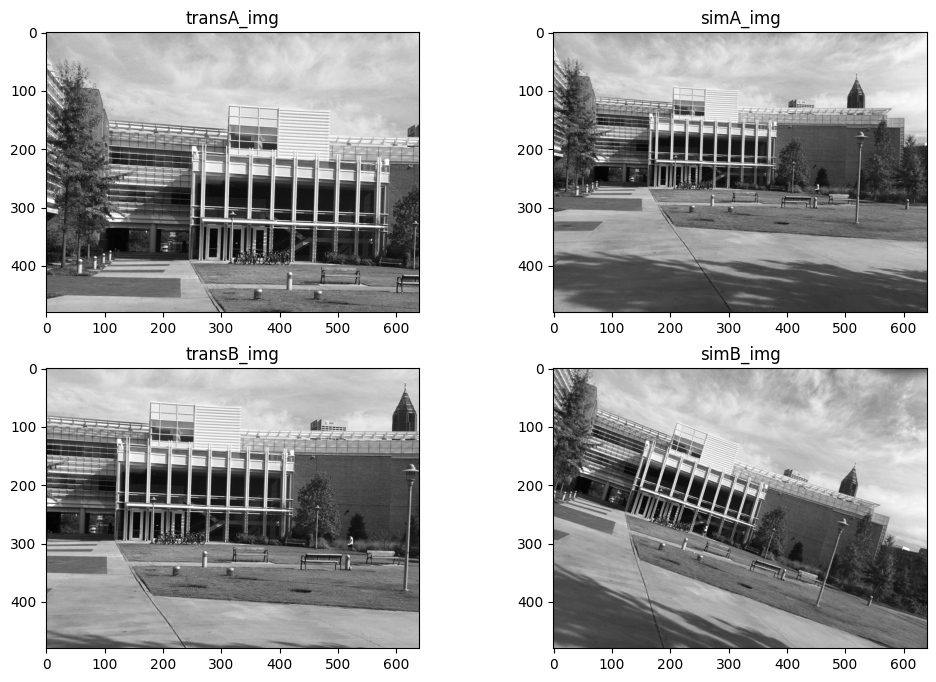

In [7]:
transA_img = cv2.imread('transA.jpg', cv2.IMREAD_GRAYSCALE)
simA_img = cv2.imread('simA.jpg', cv2.IMREAD_GRAYSCALE)
transB_img = cv2.imread('transB.jpg', cv2.IMREAD_GRAYSCALE)
simB_img = cv2.imread('simB.jpg', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.title('transA_img')
plt.imshow(transA_img, cmap='gray')
plt.subplot(2, 2, 2)
plt.title('simA_img')
plt.imshow(simA_img, cmap='gray')
plt.subplot(2, 2, 3)
plt.title('transB_img')
plt.imshow(transB_img, cmap='gray')
plt.subplot(2, 2, 4)
plt.title('simB_img')
plt.imshow(simB_img, cmap='gray')
plt.show()


## Image Gradients

In [8]:
def img_gradients(img):
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return sobel_x, sobel_y

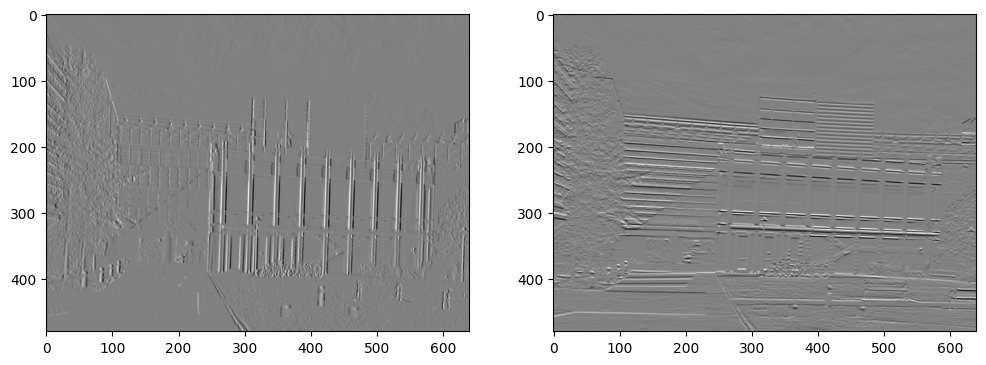

In [9]:
gradient_x, gradient_y = img_gradients(transA_img)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(gradient_x, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(gradient_y, cmap='gray')
plt.show()

## Harris Corners

In [10]:
def compute_R(I_x, I_y, window_size=5, alpha=0.04, sigma=1):
    gaussian_kernel = cv2.getGaussianKernel(window_size, sigma)
    gaussian_kernel = gaussian_kernel @ gaussian_kernel.T
    I_x2 = I_x ** 2
    I_y2 = I_y ** 2
    S_xx = cv2.filter2D(I_x2, ddepth=-1, kernel=gaussian_kernel)
    S_yy = cv2.filter2D(I_y2, ddepth=-1, kernel=gaussian_kernel)
    S_xy = cv2.filter2D(I_x * I_y, ddepth=-1, kernel=gaussian_kernel)
    det_M = S_xx * S_yy - S_xy ** 2
    trace_M = S_xx + S_yy
    return det_M - alpha * trace_M ** 2

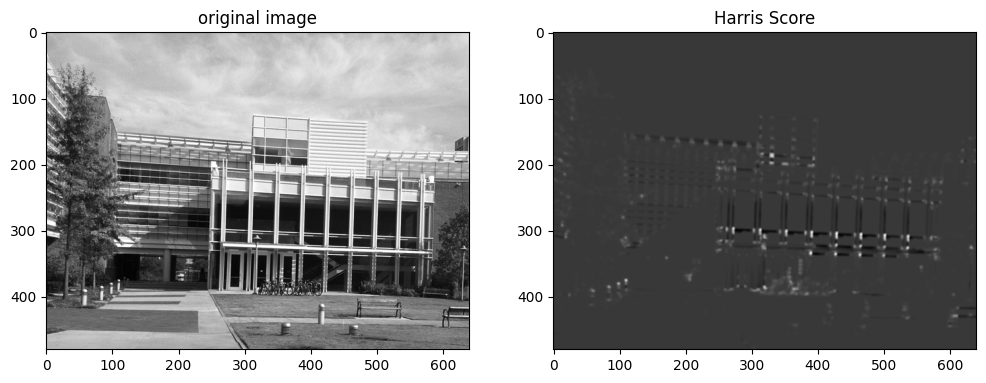

In [11]:
R = compute_R(gradient_x, gradient_y, window_size=7, sigma=2)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('original image')
plt.imshow(transA_img, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Harris Score')
plt.imshow(R, cmap='gray')
plt.show()

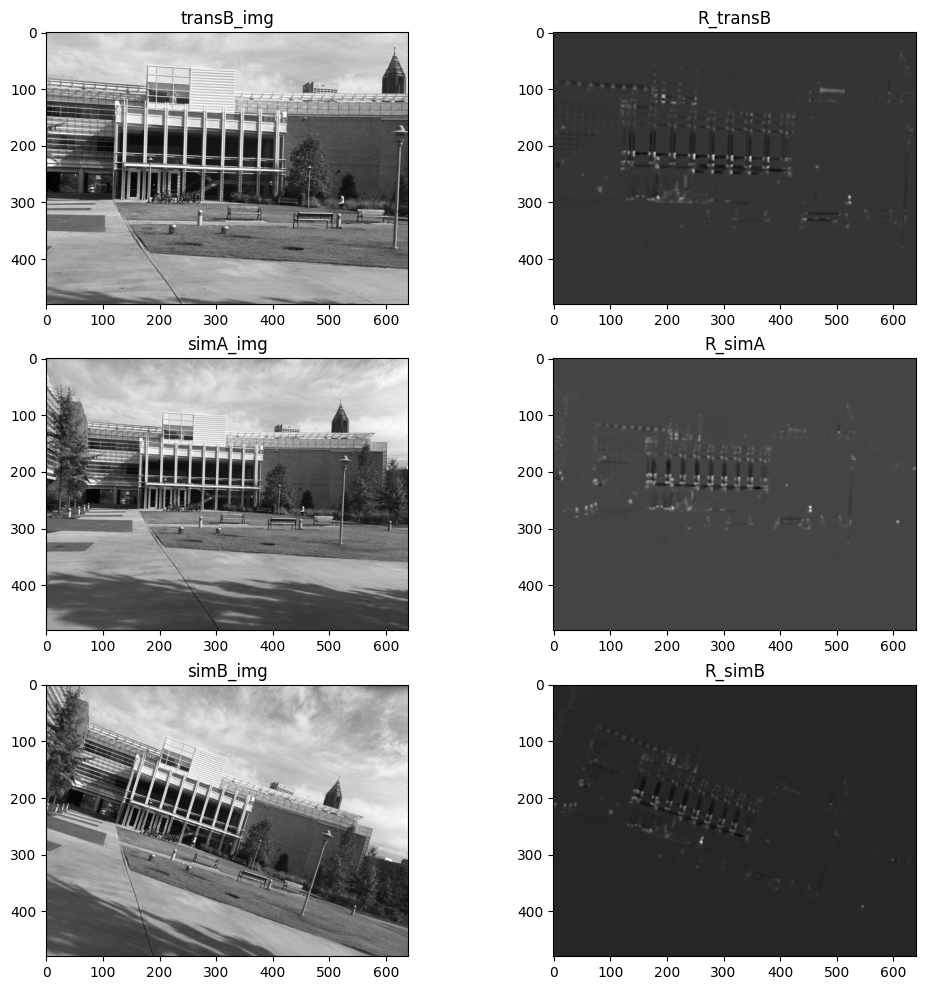

In [12]:
transB_gradient_x, transB_gradient_y = img_gradients(transB_img)
simA_gradient_x, simA_gradient_y = img_gradients(simA_img)
simB_gradient_x, simB_gradient_y = img_gradients(simB_img)
R_transB = compute_R(transB_gradient_x, transB_gradient_y, window_size=7, sigma=2)
R_simA = compute_R(simA_gradient_x, simA_gradient_y, window_size=7, sigma=2)
R_simB = compute_R(simB_gradient_x, simB_gradient_y, window_size=7, sigma=2)
plt.figure(figsize=(12, 12))
plt.subplot(3, 2, 1)
plt.title('transB_img')
plt.imshow(transB_img, cmap='gray')
plt.subplot(3, 2, 2)
plt.title('R_transB')
plt.imshow(R_transB, cmap='gray')

plt.subplot(3, 2, 3)
plt.title('simA_img')
plt.imshow(simA_img, cmap='gray')
plt.subplot(3, 2, 4)
plt.title('R_simA')
plt.imshow(R_simA, cmap='gray')

plt.subplot(3, 2, 5)
plt.title('simB_img')
plt.imshow(simB_img, cmap='gray')
plt.subplot(3, 2, 6)
plt.title('R_simB')
plt.imshow(R_simB, cmap='gray')

plt.show()

In [13]:
def threshold_R(R, pecentile=90):
    non_zero_R = R[R > 0]
    threshold = np.percentile(non_zero_R, pecentile)
    return R > threshold

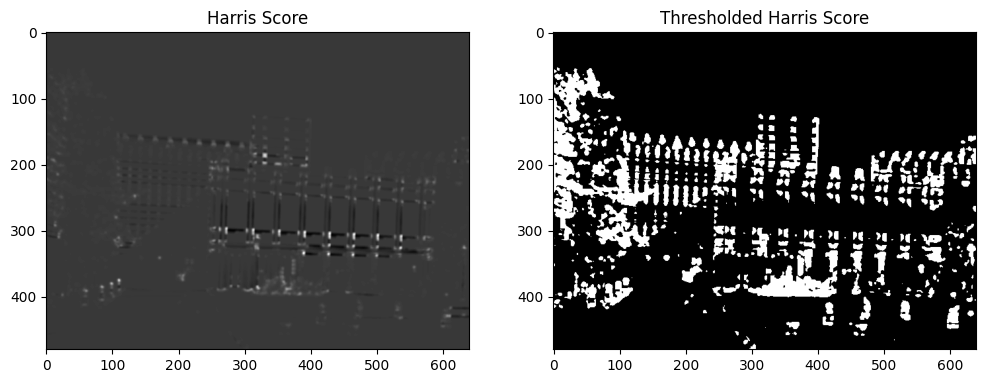

In [14]:
transA_R_threshold = threshold_R(R, 80)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Harris Score')
plt.imshow(R, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Thresholded Harris Score')
plt.imshow(transA_R_threshold, cmap='gray')
plt.show()

In [15]:
def non_max_suppression(R, window_size=20, percentile=80):
    non_zero_R = R[R > 0]
    threshold = np.percentile(non_zero_R, percentile)
    maximum_filtered = cv2.dilate(R, np.ones((window_size, window_size)))
    minimum_filtered = cv2.erode(R, np.ones((window_size, window_size)))
    R_filtered = (R == maximum_filtered) & (R != minimum_filtered) & (R > threshold)
    return R_filtered

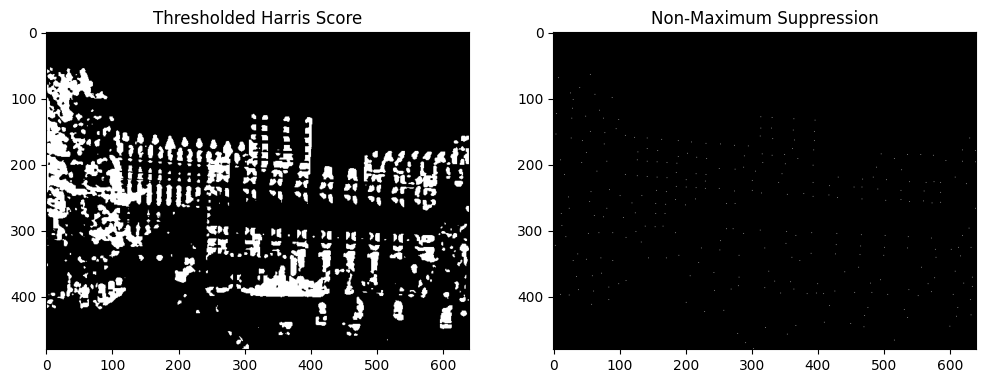

In [16]:
nms_transA_R = non_max_suppression(R)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Thresholded Harris Score')
plt.imshow(transA_R_threshold, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Non-Maximum Suppression')
plt.imshow(nms_transA_R, cmap='gray')
plt.show()

In [17]:
def display_corners_on_image(img, corners, color=(0, 255, 0)):
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for corner in corners:
        cv2.circle(img, tuple([corner[-1], corner[0]]), 3, color, -1)
    return img

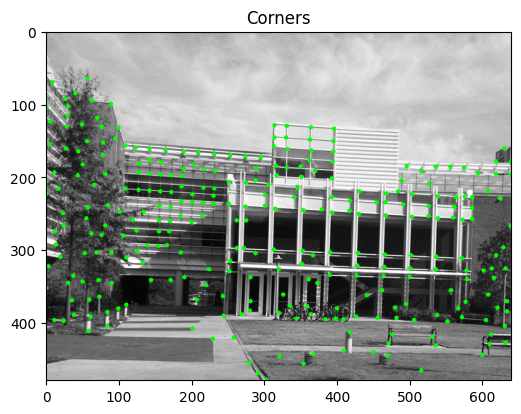

In [18]:
corner_img = display_corners_on_image(transA_img, np.argwhere(nms_transA_R))
plt.figure(figsize=(6, 6))
plt.title('Corners')
plt.imshow(corner_img)
plt.show()

## SIFT Descriptors

In [19]:
def compute_corners_angles(I_x, I_y, corners):
    gradient_angles = np.arctan2(I_y, I_x)
    corner_angles = gradient_angles[corners[:, 0], corners[:, 1]]
    return corner_angles

def draw_corner_angles(img, corners, angles):
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for corner, angle in zip(corners, angles):
        end_point = (corner + 20 * np.array([np.cos(angle), np.sin(angle)])).astype(np.int32)
        cv2.line(img, tuple([corner[-1], corner[0]]), tuple([end_point[-1], end_point[0]]), (0, 255, 0), 2)
    return img

In [20]:
corners_indices = np.argwhere(nms_transA_R)
corner_angles = compute_corners_angles(gradient_x, gradient_y, corners_indices)
corner_angles_img = draw_corner_angles(transA_img, corners_indices, corner_angles)

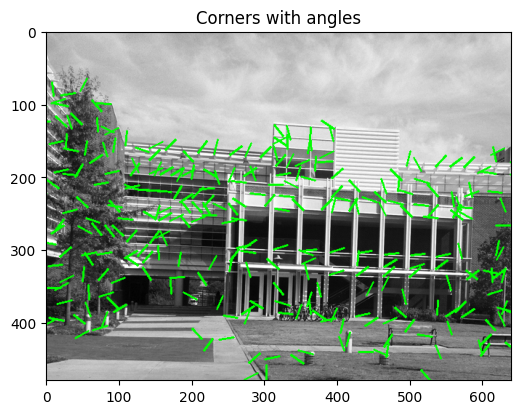

In [21]:
plt.figure(figsize=(6, 6))
plt.title('Corners with angles')
plt.imshow(corner_angles_img)
plt.show()

In [28]:
def load_keypoints(keypoints, angles):
    keypoints_sift = [cv2.KeyPoint(x=keypoint[1], y=keypoint[0], size=20, angle=np.degrees(
        angle)) for keypoint, angle in zip(keypoints, angles)]
    return keypoints_sift

In [29]:
sift = cv2.SIFT_create()
keypoints = load_keypoints(corners_indices.astype(float), corner_angles)
points, descriptors = sift.compute(transA_img, keypoints)

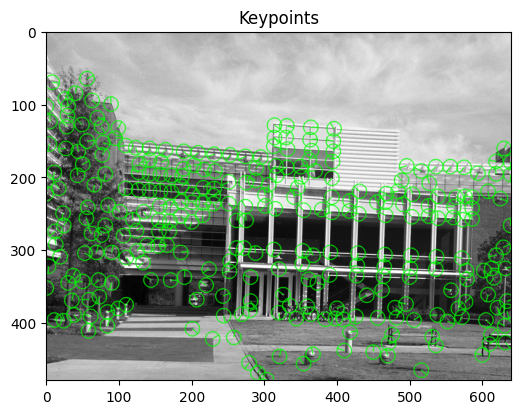

In [30]:
keypoints_img = cv2.drawKeypoints(transA_img, keypoints, None, color=(
    0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(6, 6))
plt.title('Keypoints')
plt.imshow(keypoints_img)
plt.show()